## Dataset: OASIS Cross-Sectional

- **Fuente:** Open Access Series of Imaging Studies ([oasis-brains.org](https://sites.wustl.edu/oasisbrains/home/oasis-1/))
- **Tipo:** MRI estructural (T1-weighted MPRAGE) de cerebro humano
- **Formato:** NIfTI (.hdr/.img) — pares de archivos
- **Sujetos en disc1:** ~20 sujetos (OAS1_0001 a OAS1_0020 aprox.)
- **Estructura por sujeto:**
  - RAW: 4 adquisiciones crudas del mismo cerebro
  - PROCESSED/SUBJ: imagen promediada y corregistrada
  - PROCESSED/T88: registrada al espacio estándar Talairach
  - FSL_SEG: segmentación de tejidos (GM/WM/CSF)
- **Resolución típica:** 256 × 256 × 160 vóxeles
- **Metadatos:** edad, sexo, CDR (demencia), eTIV, nWBV, ASF

In [23]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import glob, os
import pandas as pd
from scipy import stats

DATASET_ROOT = r'C:\Users\sebas\OneDrive\Documentos\Octavo semestre\Imagenes y vision\oasis_cross-sectional_disc1\disc1'

### Visualizacion 

Shape del volumen: (256, 256, 128, 1)
Rango de intensidades: [0.0, 4095.0]
Resolución vóxel (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.25), np.float32(0.0))


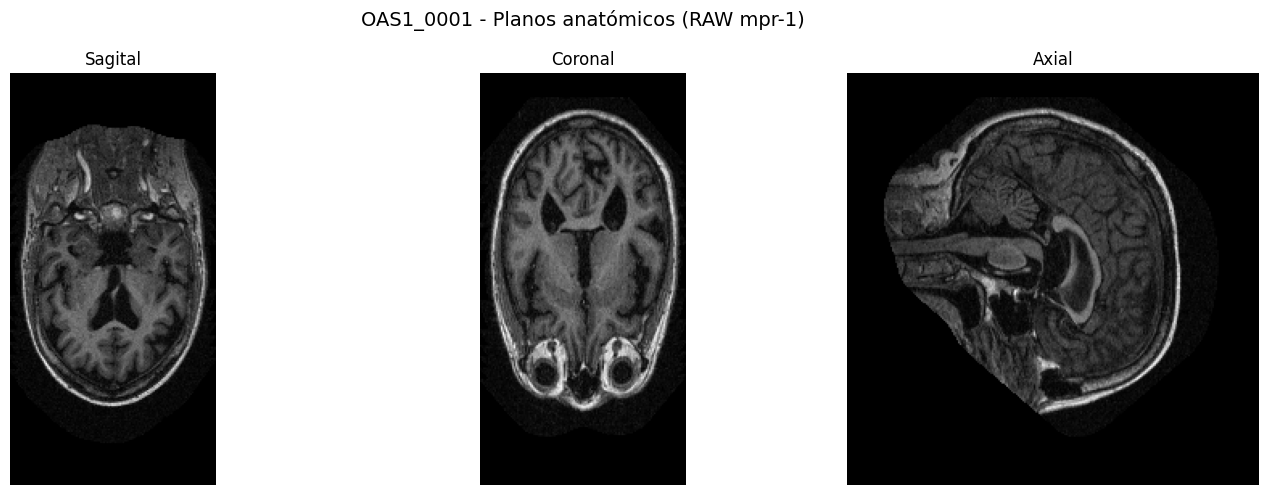

In [ ]:
# Cargar la primera imagen del data set
hdr_path = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1', 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr')
img = nib.load(hdr_path)
data = img.get_fdata()

print(f"Shape del volumen: {data.shape}")
print(f"Rango de intensidades: [{data.min():.1f}, {data.max():.1f}]")
print(f"Resolución vóxel (mm): {img.header.get_zooms()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('OAS1_0001 - Planos anatómicos (RAW mpr-1)', fontsize=14)

cx, cy, cz = data.shape[0]//2, data.shape[1]//2, data.shape[2]//2

axes[0].imshow(data[cx, :, :], cmap='gray'); axes[0].set_title('Sagital')
axes[1].imshow(data[:, cy, :], cmap='gray'); axes[1].set_title('Coronal')
axes[2].imshow(data[:, :, cz], cmap='gray'); axes[2].set_title('Axial')

for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

Se cargó el volumen MRI del sujeto OAS1_0001 en su versión cruda (RAW) para explorar los datos en su versión original. El volumen tiene dimensiones de 256 × 256 × 128 vóxeles, con una resolución espacial de 1.0 × 1.0 × 1.25 mm por vóxel, y un rango de intensidades de 0 a 4095 debido a su codificación en 12 bits. Se visualizaron los tres planos anatómicos estándar: sagital, coronal y axial, correspondientes a cortes perpendiculares a cada uno de los ejes espaciales del volumen. Esta visualización permite obtener información relevante del dato, identificar la orientación en la que se encuentran las imágenes y obtener una primera impresión visual de la calidad del dataset.

### Histogramas

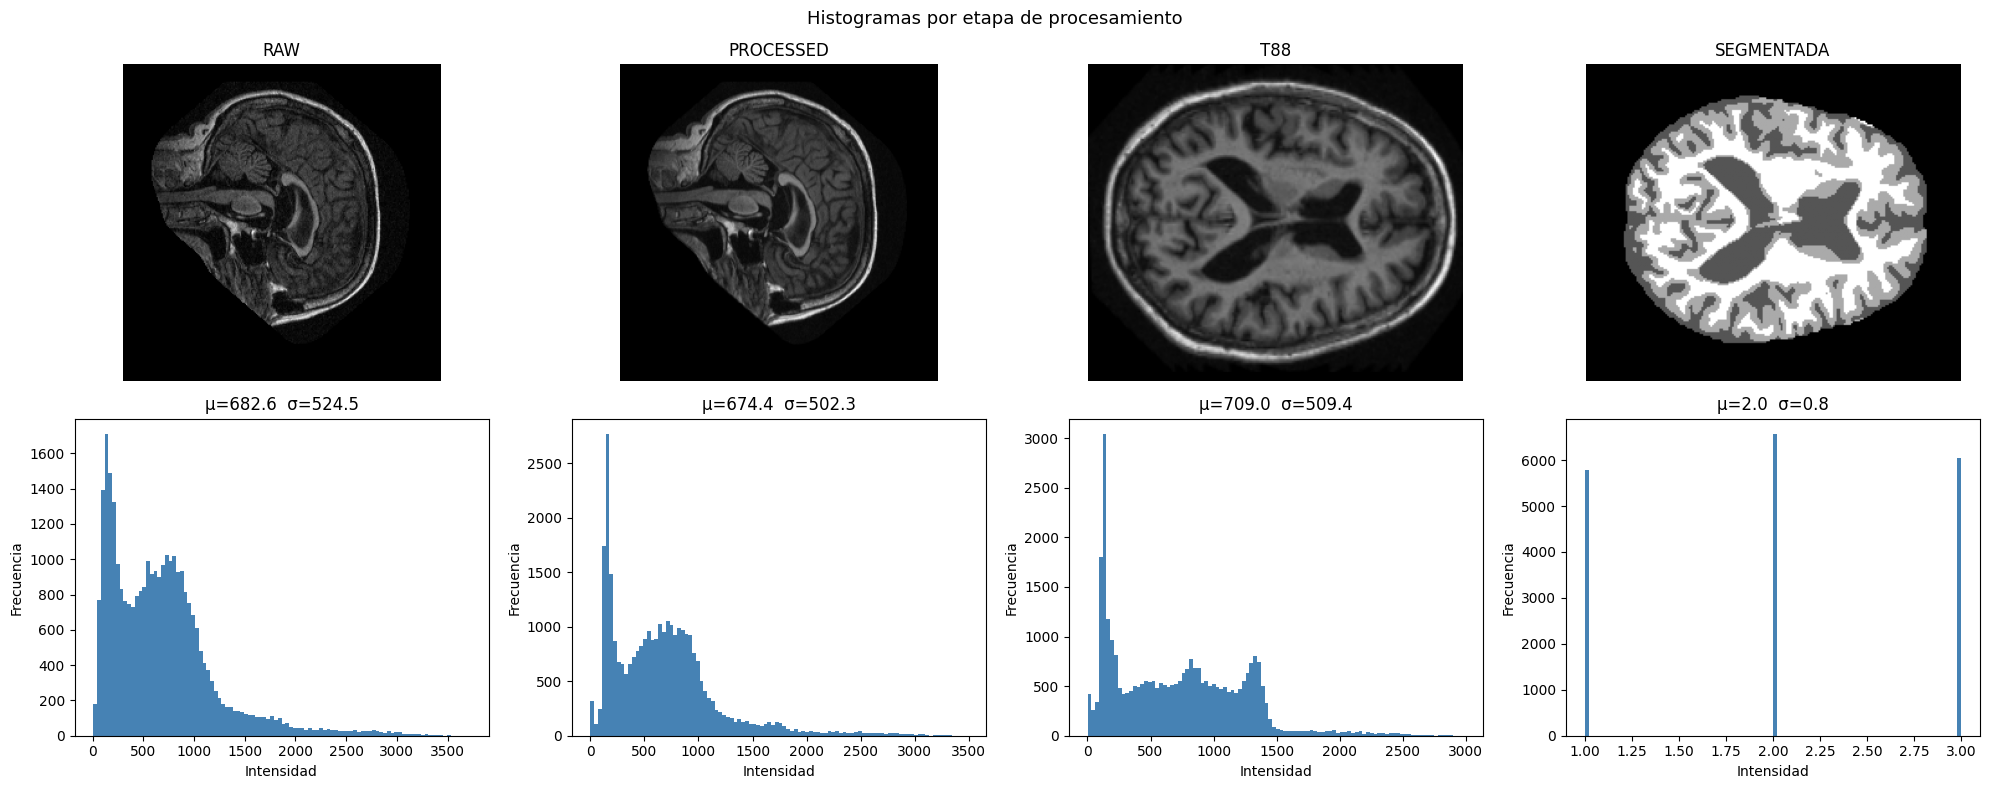

In [ ]:
from scipy.stats import skew, kurtosis

BASE = os.path.join(DATASET_ROOT, 'OAS1_0001_MR1')

paths = {'RAW': os.path.join(BASE, 'RAW', 'OAS1_0001_MR1_mpr-1_anon.hdr'), 'PROCESSED':  os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'SUBJ_111', 'OAS1_0001_MR1_mpr_n4_anon_sbj_111.hdr'), 'T88':        os.path.join(BASE, 'PROCESSED', 'MPRAGE', 'T88_111', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_gfc.hdr'), 'SEGMENTADA': os.path.join(BASE, 'FSL_SEG', 'OAS1_0001_MR1_mpr_n4_anon_111_t88_masked_gfc_fseg.hdr')}
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Histogramas por etapa de procesamiento', fontsize=13)

for col, (titulo, path) in enumerate(paths.items()):
    d = nib.load(path).get_fdata()
    slc = d[:, :, d.shape[2]//2].flatten()
    slc_no_zeros = slc[slc > 0]   
    axes[0, col].imshow(d[:, :, d.shape[2]//2], cmap='gray')
    axes[0, col].set_title(titulo); axes[0, col].axis('off')
    axes[1, col].hist(slc_no_zeros, bins=100, color='steelblue', edgecolor='none')
    axes[1, col].set_title(f'μ={np.mean(slc_no_zeros):.1f}  σ={np.std(slc_no_zeros):.1f}')
    axes[1, col].set_xlabel('Intensidad'); axes[1, col].set_ylabel('Frecuencia')

plt.tight_layout(); plt.show()

Se analizaron los histogramas de intensidad del sujeto OAS1_0001 en sus cuatro versiones disponibles: RAW, PROCESSED, T88 y SEGMENTADA, tomando el slice axial central de cada volumen y excluyendo los píxeles de fondo. Para las versiones RAW y PROCESSED es posible observar un histograma con una distribución asimétrica positiva, lo cual es esperado en este tipo de imágenes, ya que la mayoría de sus píxeles corresponden a tejidos de intensidad media-baja (materia gris) y una minoría corresponde a tejidos más brillantes (materia blanca). Para la versión T88 se obtiene un histograma similar al anterior, pero con una distribución más uniforme, resultado del registro al espacio estándar de Talairach. Por último, la versión SEGMENTADA presenta un histograma discreto con tres valores posibles: 1 = materia gris, 2 = materia blanca, 3 = LCR (líquido cefalorraquídeo).

In [ ]:
all_hdrs = sorted(glob.glob(
    os.path.join(DATASET_ROOT, '**', 'RAW', '*mpr-1_anon.hdr'), recursive=True
))

print(f"Total de sujetos encontrados: {len(all_hdrs)}")

registros = []
for path in all_hdrs:
    partes = path.replace('\\', '/').split('/')
    sujeto = next((p for p in partes if p.startswith('OAS1_')), 'desconocido')    
    img_ras = nib.as_closest_canonical(nib.load(path))
    d = img_ras.get_fdata().squeeze()   
    
    registros.append({
        'Sujeto':    sujeto,
        'Shape':     d.shape,
        'Min':       round(d.min(), 1),
        'Max':       round(d.max(), 1),
        'Media':     round(np.mean(px), 1),
        'StdDev':    round(np.std(px), 1),
        'Skewness':  round(skew(px), 3),
        'Kurtosis':  round(kurtosis(px), 3)
    })

df = pd.DataFrame(registros)
print(df.to_string(index=False))

Total de sujetos encontrados: 39
       Sujeto           Shape  Min    Max  Media  StdDev  Skewness  Kurtosis
OAS1_0001_MR1 (256, 256, 128)  0.0 4095.0  807.2   674.7     1.184     1.395
OAS1_0002_MR1 (256, 256, 128)  0.0 4095.0  892.5   711.3     1.019     0.817
OAS1_0003_MR1 (256, 256, 128)  0.0 4095.0  852.6   705.8     1.077     0.933
OAS1_0004_MR1 (256, 256, 128)  0.0 4095.0  779.7   616.0     1.020     1.051
OAS1_0005_MR1 (256, 256, 128)  0.0 4095.0  776.3   543.2     0.731     0.352
OAS1_0006_MR1 (256, 256, 128)  0.0 4095.0  797.8   687.0     1.243     1.675
OAS1_0007_MR1 (256, 256, 128)  0.0 4095.0  836.2   603.7     0.766     0.448
OAS1_0009_MR1 (256, 256, 128)  0.0 4095.0  781.8   648.0     1.138     1.345
OAS1_0010_MR1 (256, 256, 128)  0.0 4095.0  846.3   638.7     1.023     0.957
OAS1_0011_MR1 (256, 256, 128)  0.0 4095.0  801.5   686.5     1.182     1.243
OAS1_0012_MR1 (256, 256, 128)  0.0  408.0   75.3    52.9     0.775     0.428
OAS1_0013_MR1 (256, 256, 128)  0.0 4095.0  

Se procesaron los 39 sujetos disponibles en el disco 1 del dataset OASIS, 
todos con dimensiones consistentes de 256 × 256 × 128 vóxeles y rango de 
intensidades de 0 a 4095. Para cada uno se calcularon las siguientes estadisticas de los pixeles de tejido excluyendo su fondo: media, desviación 
estándar, asimetría (skewness) y curtosis (kurtosis). La media de intensidades 
varía entre sujetos en el rango aproximado de 42 a 1009, reflejando diferencias en el brillo global de cada adquisición. La asimetría es positiva en todos los casos (valores entre 0.7 y 1.3), confirmando la distribución característica de MRI T1 con cola hacia intensidades altas. Se destacan dos sujetos atipicos (OAS1_0012 y OAS1_0019) con un valores maximos fuera de lo comun, lo que sugiere posibles diferencias en los parametros de adquisicion o normzalicion.

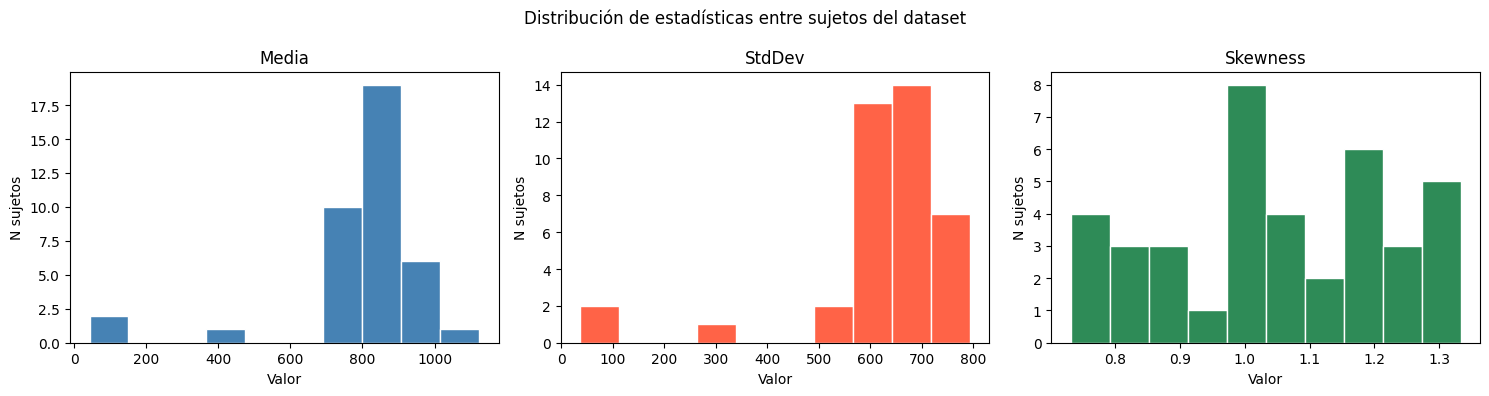

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de estadísticas entre sujetos del dataset')

for ax, col, color in zip(axes, ['Media', 'StdDev', 'Skewness'], ['steelblue','tomato','seagreen']):
    ax.hist(df[col], bins=10, color=color, edgecolor='white')
    ax.set_title(col); ax.set_xlabel('Valor'); ax.set_ylabel('N sujetos')

plt.tight_layout(); plt.show()

Ahora se evalua la homogeneidad del dataset, se analizó la distribución 
de tres estadísticas clave a través de los 39 sujetos disponibles en el disco 1. En cuanto a la media de intensidades, la mayoría de los sujetos se concentra en el rango de 800 a 900 unidades de intensidad, con algunos casos atípicos de valores muy bajos (cercanos a 0-200) que corresponden a los sujetos con rango dinámico reducido identificados anteriormente. La desviación estándar se agrupa predominantemente entre 600 y 700, lo que indica que la variabilidad interna de las imágenes es consistente entre sujetos y refleja un contraste similar entre tejidos en la mayoría de los casos. La asimetría (skewness) presenta valores entre 0.7 y 1.3 en todos los sujetos, con una concentración alrededor de 1.0, confirmando que el histograma de intensidades de las imágenes MRI T1 del dataset tiene una distribución asimétricamente positiva de forma consistente. 